# PBS Utah Major-Donor Prediction — Exploratory Data Analysis

**IS 6813 MSBA Capstone · Fall 2026** · Kate Klinger

## Table of Contents
1. [Introduction](#1.-Introduction)
2. [Setup and data loading](#2.-Setup-and-data-loading)
3. [Description of the data](#3.-Description-of-the-data)
4. [Data quality and missing data](#4.-Data-quality-and-missing-data)
5. [Building donor fiscal-year giving](#5.-Building-donor-fiscal-year-giving)
6. [The target: major-donor conversion](#6.-The-target:-major-donor-conversion)
7. [Giving history as predictors](#7.-Giving-history-as-predictors)
8. [Constituent attributes and leakage](#8.-Constituent-attributes-and-leakage)
9. [Solicitations](#9.-Solicitations)
10. [Passport viewing](#10.-Passport-viewing)
11. [The cultivation program](#11.-The-cultivation-program)
12. [Simple ranking baselines](#12.-Simple-ranking-baselines)
13. [Results](#13.-Results)

## 1. Introduction

### Business problem
Congress ended federal funding for public broadcasting in 2025, leaving PBS Utah with a recurring shortfall. **Major donors**, people who give **$1,200 or more in a fiscal year**, are the most valuable donors, but PBS Utah has no reliable, data-driven way to tell which of its tens of thousands of smaller donors are most likely to become major donors. Gift officers can only cultivate about 1,000 donors a year (eight portfolios of 125), so they need a **ranked prospect list** that puts the likeliest future major donors at the top.

### Analytic problem
The unit of analysis is the **donor-year**. At the end of each fiscal year *t*, every donor who gave in FY *t* but gave **less than $1,200** is eligible. Using only information available by the end of FY *t*, predict:

- **12-month conversion (primary target):** giving of $1,200 or more in FY *t + 1*
- **Longer-term conversion:** $1,200 or more in any of FY *t + 1* to *t + 3*, or *t + 1* to *t + 5*

Major gifts are rare, so this is a rare-event classification problem. A model will be judged on how many future converters it places in the top ~1,000 of the list (recall, precision, and lift at K), compared against simple rules that staff could apply without a model.

### Questions guiding this EDA
1. How are the tables related, and do the keys join cleanly?
2. What data quality problems (duplicates, placeholders, constant columns) must be fixed before giving can be summed?
3. How rare is major giving, and what are the 12-month, 3-year, and 5-year conversion base rates?
4. Which parts of a donor's history are associated with converting to major giving?
5. Which constituent fields are usable, and which are snapshot fields that would leak the future?
6. Do solicitations or Passport viewing add information beyond giving history?
7. What does the randomized cultivation holdout reveal about the effect of officer contact?
8. How well do simple ranking rules already find converters, i.e., what must a model beat?

## 2. Setup and data loading

The data come from the [course repository](https://github.com/jefftwebb/donor_prediction_capstone_project). Several tables are stored with Git LFS, so clone the repository and run `git lfs pull` (a GitHub ZIP download gives tiny pointer files instead of data). Point `DATA_DIR` at the `tables/` folder. The CSVs are not committed to this repository.

All rows are **synthetic**; no row is a real person or gift.

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import numpy as np
import pandas as pd
import seaborn as sns

DATA_DIR = Path("../data/tables")  # folder holding the course CSVs
MAJOR = 1200  # major-donor threshold: $1,200+ in a fiscal year
K = 1000      # prospect-list size: 8 portfolios x 125 donors

pd.set_option("display.max_columns", 50)
pd.set_option("display.width", 160)
pd.set_option("display.float_format", "{:,.2f}".format)
sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams["figure.dpi"] = 110
BLUE, ORANGE, GREY = "#2a6fdb", "#e8833a", "#9aa0a6"


def to_fy(dates):
    # PBS Utah fiscal years run July-June; FY2026 = July 2025 - June 2026
    dates = pd.to_datetime(dates)
    return dates.dt.year + (dates.dt.month >= 7).astype(int)

In [2]:
con = pd.read_csv(DATA_DIR / "constituents_w_memberships.csv", low_memory=False)
pay = pd.read_csv(DATA_DIR / "unite_payments.csv", parse_dates=["credit_date"])
soft = pd.read_csv(DATA_DIR / "soft_credits.csv", parse_dates=["Credit Date"])
legacy = pd.read_csv(DATA_DIR / "team_approach_legacy_payments.csv", low_memory=False, parse_dates=["gift_date"])
codes = pd.read_csv(DATA_DIR / "campaign_codes.csv")
members = pd.read_csv(
    DATA_DIR / "campaign_members.csv",
    usecols=["constituent_id", "marketing_code", "responded", "campaign_start_date"],
    dtype={"constituent_id": "category", "marketing_code": "category"},
)
passport = pd.read_csv(DATA_DIR / "passport_viewing.csv")
cult = pd.read_csv(DATA_DIR / "cultivation.csv")
portfolios = pd.read_csv(DATA_DIR / "officer_portfolios.csv")

pay["fy"] = to_fy(pay["credit_date"])
soft["fy"] = to_fy(soft["Credit Date"])
legacy["fy"] = to_fy(legacy["gift_date"])
members["fy"] = pd.to_datetime(members["campaign_start_date"]).dt.year + 1

## 3. Description of the data

Nine tables are available. The inventory below gives each table's size, grain, and whether its documented key is actually unique.

In [3]:
tables = {
    "constituents_w_memberships": (con, "Constituent ID", "Constituent (people + orgs)"),
    "unite_payments": (pay, "payment_id", "Payment, FY2021-FY2026"),
    "soft_credits": (soft, "Credit ID", "Soft credit, FY2021-FY2026"),
    "team_approach_legacy_payments": (legacy, None, "Legacy gift, before FY2021"),
    "campaign_codes": (codes, "Marketing Code", "Marketing code"),
    "campaign_members": (members, None, "Solicitation, FY2021-FY2026"),
    "passport_viewing": (passport, ["constituent_id", "fiscal_year", "genre"], "Constituent x FY x genre"),
    "cultivation": (cult, ["synthetic_id", "fiscal_year"], "Donor-year cultivation assignment"),
    "officer_portfolios": (portfolios, "portfolio_id", "Officer portfolio"),
}
inventory = pd.DataFrame(
    [
        {
            "table": name,
            "rows": len(df),
            "columns": df.shape[1],
            "grain": grain,
            "key": key if key else "(none documented)",
            "key unique?": (not df.duplicated(key).any()) if key else "n/a",
        }
        for name, (df, key, grain) in tables.items()
    ]
)
inventory

,table,rows,columns,grain,key,key unique?
0,constituents_w_memberships,196167,22,Constituent (people + orgs),Constituent ID,True
1,unite_payments,1722698,14,"Payment, FY2021-FY2026",payment_id,True
2,soft_credits,4145,10,"Soft credit, FY2021-FY2026",Credit ID,False
3,team_approach_legacy_payments,1202857,45,"Legacy gift, before FY2021",(none documented),n/a
4,campaign_codes,29249,17,Marketing code,Marketing Code,True
5,campaign_members,5233404,5,"Solicitation, FY2021-FY2026",(none documented),n/a
6,passport_viewing,444741,5,Constituent x FY x genre,"[constituent_id, fiscal_year, genre]",True
7,cultivation,4000,7,Donor-year cultivation assignment,"[synthetic_id, fiscal_year]",True
8,officer_portfolios,8,4,Officer portfolio,portfolio_id,True


### How the tables join

```
constituents_w_memberships (Constituent ID)
 ├── unite_payments.donor_id
 ├── soft_credits."Soft Credit Constituent ID"
 ├── team_approach_legacy_payments.constituent_id_1 … _7   (household rows)
 ├── campaign_members.constituent_id ── campaign_codes."Marketing Code"
 ├── passport_viewing.constituent_id
 └── cultivation.synthetic_id ── officer_portfolios.portfolio_id
```

In [4]:
ids = set(con["Constituent ID"])
links = {
    "payments.donor_id": pay["donor_id"],
    "soft_credits recipient": soft["Soft Credit Constituent ID"],
    "legacy.constituent_id_1": legacy["constituent_id_1"],
    "campaign_members.constituent_id": members["constituent_id"].astype(str),
    "passport.constituent_id": passport["constituent_id"],
    "cultivation.synthetic_id": cult["synthetic_id"],
    "payments.marketing_code -> codes": pay["marketing_code"],
}
targets = {"payments.marketing_code -> codes": set(codes["Marketing Code"])}
link_check = pd.DataFrame(
    {name: {"rows": len(s), "share matched": s.isin(targets.get(name, ids)).mean(),
            "unmatched values": sorted(set(s.dropna().astype(str)) - targets.get(name, ids))[:3]}
     for name, s in links.items()}
).T
link_check.loc["cultivation.portfolio_id -> portfolios"] = [len(cult), cult["portfolio_id"].isin(portfolios["portfolio_id"]).mean(), []]
link_check

,rows,share matched,unmatched values
payments.donor_id,1722698,0.98,[SYN-ORPHAN]
soft_credits recipient,4145,0.98,[SYN-ORPHAN]
legacy.constituent_id_1,1202857,0.82,[]
campaign_members.constituent_id,5233404,1.00,[]
passport.constituent_id,444741,1.00,[]
cultivation.synthetic_id,4000,1.00,[]
payments.marketing_code -> codes,1722698,1.00,[SYN-ORPHAN]
cultivation.portfolio_id -> portfolios,4000,1.00,[]


**Join findings.**
- Every documented key is unique **except** `soft_credits."Credit ID"`, which has 79 exact-duplicate rows (a known issue in the dictionary).
- The only unmatched IDs are `SYN-ORPHAN`: about 2% of payment rows, 79 soft credits, and 1,225 payments whose marketing code is `SYN-ORPHAN`. 18% of legacy rows link to no constituent. The next section shows that **all of these are defective copies of real rows**, not missing donors.
- Legacy rows link through `constituent_id_1`/`_2` only; `_3`–`_7` are always blank.
- `Designation Detail ID` is **not** a usable join key between soft credits and payments. Two values ("Designation 1" and "Other") cover about 880,000 payments, so a merge on it explodes.

## 4. Data quality and missing data

### Defective copies of real records

The unmatched `SYN-ORPHAN` payments look like gifts with no donor, but their row IDs say otherwise. Real payments have IDs starting `SYN-PAY-`; some rows have IDs such as `SYN-DEF-unmatched_constituent-…`, naming the defect. Similarly, every legacy row with no linked constituent has an account ID starting `SYN-UNMATCHED-`. The check below tests whether each defect row is a **copy** of a real row: does a real row match it on every column except the row ID and the one broken field?

In [5]:
pay["kind"] = pay["payment_id"].str.extract(r"^SYN-DEF-([a-z_]+)")[0].fillna("real")
soft["kind"] = soft["Credit ID"].str.extract(r"^SYN-DEF-([a-z_]+)")[0].fillna("real")
broken = {
    "unmatched_constituent": {"pay": "donor_id", "soft": "Soft Credit Constituent ID"},
    "unmatched_campaign": {"pay": "marketing_code"},
    "nonpositive_amount": {"pay": "payment_amount", "soft": "Credit Amount"},
}


def twins(df, id_col, field, kind):
    # share of defect rows that match a real row on everything except the row ID and the broken field
    on = [c for c in df.columns if c not in (id_col, field, "kind")]
    bad, real = df[df["kind"] == kind], df[df["kind"] == "real"].drop_duplicates(on)
    return len(bad), bad.merge(real[on], on=on, how="inner").shape[0]


rows = []
for kind, fields in broken.items():
    for tbl, field in fields.items():
        df, id_col, amt = (pay, "payment_id", "payment_amount") if tbl == "pay" else (soft, "Credit ID", "Credit Amount")
        n, matched = twins(df, id_col, field, kind)
        rows.append({"table": tbl, "defect": kind, "broken field": field, "rows": n,
                     "amount ($)": df.loc[df["kind"] == kind, amt].sum(), "rows with a real twin": matched})

# legacy: unmatched rows vs. linked rows, matching on every non-ID column
id_cols = [f"constituent_id_{i}" for i in range(1, 8)]
leg_on = [c for c in legacy.columns if c not in ["ta_account_id", "source_code", *id_cols]]
leg_bad = legacy[legacy["ta_account_id"].str.startswith("SYN-UNMATCHED")]
leg_real = legacy[~legacy["ta_account_id"].str.startswith("SYN-UNMATCHED")]
leg_twins = leg_bad.merge(leg_real[leg_on].drop_duplicates(), on=leg_on, how="inner").shape[0]
rows.append({"table": "legacy", "defect": "SYN-UNMATCHED account", "broken field": "constituent IDs", "rows": len(leg_bad),
             "amount ($)": leg_bad["payment_amount"].sum(), "rows with a real twin": leg_twins})
defects = pd.DataFrame(rows)
defects.style.format({"rows": "{:,}", "amount ($)": "${:,.0f}", "rows with a real twin": "{:,}"})

,table,defect,broken field,rows,amount ($),rows with a real twin
0,pay,unmatched_constituent,donor_id,"33,733","$433,233","33,733"
1,soft,unmatched_constituent,Soft Credit Constituent ID,79,"$30,768",79
2,pay,unmatched_campaign,marketing_code,"1,225","$14,297","1,225"
3,pay,nonpositive_amount,payment_amount,"1,086",$0,"1,086"
4,soft,nonpositive_amount,Credit Amount,34,$0,34
5,legacy,SYN-UNMATCHED account,constituent IDs,"216,128","$6,299,033","216,128"


**Every defect row has a real twin.** Each one matches a real row on every other column, so these rows are duplicates with one field broken, not separate gifts:
- **36,044 Unite payments ($447,530):** 33,733 with the donor replaced by `SYN-ORPHAN`, 1,225 with the marketing code replaced by `SYN-ORPHAN`, and 1,086 with the amount set to $0.
- **113 soft credits:** 79 with the recipient replaced by `SYN-ORPHAN` and 34 with the amount set to $0.
- **216,128 legacy rows ($6.3M):** every unlinked legacy gift.

The dictionary describes orphan rows as unmatched gifts, but these are copies. Counting them would double-count revenue, and the 1,225 copied rows that still carry a valid donor ID would double-count that donor's giving. **All defect rows are dropped.** One consequence: the data cannot show which real donors have incomplete legacy histories. These findings should be reported to Jeff.

### Missing values

In [6]:
def missing_summary(df, name):
    out = df.isna().mean().rename("share missing").to_frame()
    out["table"] = name
    return out[out["share missing"] > 0]

miss = pd.concat([missing_summary(df, name) for name, (df, _, _) in tables.items()])
miss.sort_values("share missing", ascending=False)

,share missing,table
UofU Employment Status,1.00,constituents_w_memberships
Latest UofU Degree Year,1.00,constituents_w_memberships
UofU Degree Info,1.00,constituents_w_memberships
county,1.00,team_approach_legacy_payments
program,1.00,team_approach_legacy_payments
premium_1_code,1.00,team_approach_legacy_payments
premium_1_name,1.00,team_approach_legacy_payments
premium_2_code,1.00,team_approach_legacy_payments
premium_2_name,1.00,team_approach_legacy_payments
premium_3_code,1.00,team_approach_legacy_payments


### Constant and placeholder columns

Because the data are synthetic, many columns hold a single placeholder value (e.g., `"Synthetic"`). These carry no information and should be dropped before modeling.

In [7]:
constant = pd.DataFrame(
    [
        {"table": name, "column": c}
        for name, (df, _, _) in tables.items()
        for c in df.columns
        if c != "kind" and df[c].nunique(dropna=True) <= 1
    ]
)
print(f"{len(constant)} columns are constant or entirely blank")
constant.groupby("table")["column"].apply(list).to_frame("constant / blank columns")

59 columns are constant or entirely blank


,constant / blank columns
table,
campaign_codes,"[Source Category, Activity, Activity Type, Cam..."
constituents_w_memberships,"[Address City, UofU Degree Count, UofU Degree ..."
cultivation,[selected]
officer_portfolios,[capacity]
soft_credits,"[Credit Gift Type, Credit Type]"
team_approach_legacy_payments,"[activity_type, campaign, initiative, effort, ..."
unite_payments,[pledge_gift_status]


### Other quality checks

In [8]:
org_ids = con.loc[con["Primary Constituent Type"] == "Organization", "Constituent ID"].tolist()
real_soft = soft[soft["kind"] == "real"]
checks = {
    "Exact duplicate soft-credit rows (among real credits)": real_soft.duplicated().sum(),
    "Payments from organization records": pay["donor_id"].isin(org_ids).sum(),
    "Legacy rows linked to 2+ constituents": legacy["constituent_id_2"].notna().sum(),
    "Payments with tender_type 'Legacy' (undocumented value)": (pay["tender_type"] == "Legacy").sum(),
    "Constituents who are organizations": len(org_ids),
}
pd.Series(checks, name="count").to_frame().style.format("{:,}")

,count
Exact duplicate soft-credit rows (among real credits),79
Payments from organization records,"3,959"
Legacy rows linked to 2+ constituents,"9,440"
Payments with tender_type 'Legacy' (undocumented value),"735,793"
Constituents who are organizations,2


In [9]:
print("Organization hard-credit payments vs. deduplicated soft credits by FY ($):")
org_by_fy = pay[pay["donor_id"].isin(org_ids)].groupby("fy")["payment_amount"].sum()
soft_by_fy = real_soft.drop_duplicates().groupby("fy")["Credit Amount"].sum()
pd.DataFrame({"org hard-credit payments": org_by_fy, "soft credits (deduplicated)": soft_by_fy})

Organization hard-credit payments vs. deduplicated soft credits by FY ($):


,org hard-credit payments,soft credits (deduplicated)
fy,,
2021,293983,293983
2022,256336,256336
2023,306789,306789
2024,207215,207215
2025,291451,290061
2026,448065,448051


**Other data-quality findings and how I will handle them.**

| Issue | Handling |
|---|---|
| **59 constant or blank columns.** In the legacy table only `gift_kind`, `gift_type`, `gift_date`, `payment_amount`, `state`, `zip`, and the ID columns carry information. In `campaign_codes` only `Communication Method` varies. UofU degree and employment fields are blank throughout. | Drop them. |
| **Organization payments mirror soft credits.** Once the defect rows are removed, `SYN-ORG-*` hard-credit payments equal the soft credits almost to the dollar every year (FY2021–24 exactly). They are the same money. | Count it once, as the person's giving via the soft credit. Exclude org rows from donor-level giving. |
| 79 exact-duplicate soft credits. | Drop the extra copies. |
| `Major Donor Class` is 99.7% blank. `Marital Status` only ever says "Married" (91% blank). | Treat blank as "not recorded", not as a category like "single". |
| `Address City` is a placeholder (26% blank). | Use state / ZIP instead. |
| `tender_type = "Legacy"` appears on 43% of Unite payments but is not in the reference dictionary. | Don't rely on tender type; ask Jeff what it means. |
| `rollout_fy` is blank for one portfolio (P08). | Blank means the portfolio never adopted the program. It is not missing data. |

## 5. Building donor fiscal-year giving

Following the Student Data Dictionary, a donor's **fiscal-year giving** is the sum of positive payments the constituent made plus positive soft credits assigned to the constituent, after duplicates are removed. Concretely:

1. Drop every `SYN-DEF-` payment and soft credit (defective copies, Section 4).
2. Drop exact-duplicate soft-credit rows.
3. Drop organization payments (`SYN-ORG-*`); the same gifts reach people as soft credits, so counting both would double count.
4. Keep positive amounts only.

In [10]:
real_pay = pay[pay["kind"] == "real"]
person_pay = real_pay[(real_pay["payment_amount"] > 0) & ~real_pay["donor_id"].isin(org_ids)]
person_soft = real_soft.drop_duplicates()
person_soft = person_soft[person_soft["Credit Amount"] > 0]

gifts = pd.concat(
    [
        person_pay[["donor_id", "fy", "payment_amount"]].rename(columns={"payment_amount": "amount"}).assign(source="payment"),
        person_soft.rename(columns={"Soft Credit Constituent ID": "donor_id", "Credit Amount": "amount"})[["donor_id", "fy", "amount"]].assign(source="soft credit"),
    ]
)
giving = gifts.groupby(["donor_id", "fy"], as_index=False)["amount"].sum()

# wide donor x FY matrix, 0 = no giving that year
wide = giving.pivot(index="donor_id", columns="fy", values="amount").fillna(0)
print(f"{len(giving):,} donor-years from {giving['donor_id'].nunique():,} donors")
wide.head()

199,772 donor-years from 71,811 donors


fy,2021,2022,2023,2024,2025,2026
donor_id,,,,,,
S00000002,8.00,0.00,0.00,0.00,0.00,0.00
S00000003,0.00,0.00,24.00,6.00,5.00,0.00
S00000007,0.00,0.00,5.00,5.00,5.00,0.00
S00000011,12.00,5.00,0.00,0.00,0.00,0.00
S00000013,250.00,6.00,6.00,6.00,11.00,5.00


### Revenue by year

,Individual payments,Org hard credits (DAF / sponsor),total,Removed defective copies (not revenue)
fy,,,,
2021,2.64,0.29,2.93,0.07
2022,2.67,0.26,2.93,0.06
2023,2.88,0.31,3.19,0.07
2024,2.93,0.21,3.14,0.06
2025,2.97,0.29,3.26,0.11
2026,3.74,0.45,4.19,0.08


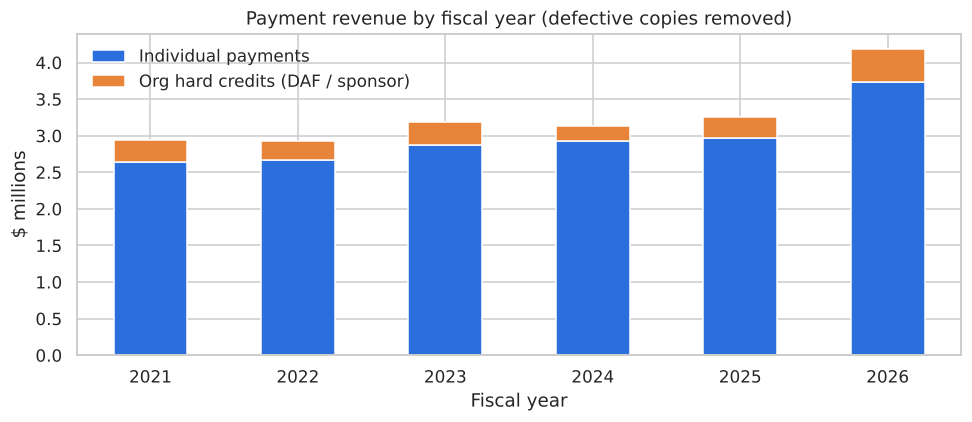

In [11]:
rev = pd.DataFrame({
    "Individual payments": person_pay.groupby("fy")["payment_amount"].sum(),
    "Org hard credits (DAF / sponsor)": real_pay[real_pay["donor_id"].isin(org_ids)].groupby("fy")["payment_amount"].sum(),
})
removed = pay[pay["kind"] != "real"].groupby("fy")["payment_amount"].sum().rename("Removed defective copies (not revenue)")
ax = (rev / 1e6).plot.bar(stacked=True, figsize=(9, 4), color=[BLUE, ORANGE], rot=0)
ax.set(title="Payment revenue by fiscal year (defective copies removed)", xlabel="Fiscal year", ylabel="$ millions")
ax.legend(frameon=False)
plt.tight_layout()
(rev / 1e6).round(2).assign(total=lambda d: d.sum(axis=1)).join((removed / 1e6).round(3))

With the defective copies removed, payment revenue held at **$2.9–3.3M a year** from FY2021 to FY2025, then **jumped 28% to $4.19M in FY2026**. That year federal funding ended and new donors flooded in. Organization hard credits make up 7–11% each year. The removed copies ($60–110K a year) are **not** revenue. If FY2026 is the test year, the model will be scored on a year that looks different from the years it learned from.

### Legacy history

Legacy (Team Approach) rows are household gifts that can list several constituents. After dropping the `SYN-UNMATCHED` copies, each linked person gets the household's gift credited to them **for history features only** (did this person's household give, and how much, before FY2021). These amounts are never added to revenue.

In [12]:
leg_long = leg_real.melt(id_vars=["fy", "payment_amount"], value_vars=id_cols, value_name="donor_id").dropna(subset=["donor_id"])
legacy_giving = leg_long.groupby(["donor_id", "fy"])["payment_amount"].sum()
legacy_wide = legacy_giving.unstack(fill_value=0)
print(f"Legacy history for {len(legacy_wide):,} people, FY{legacy_wide.columns.min()}-FY{legacy_wide.columns.max()}")
print("Linked legacy rows by fiscal year (every 4th year):")
leg_real.groupby("fy").size().iloc[::4]

Legacy history for 109,284 people, FY1984-FY2020
Linked legacy rows by fiscal year (every 4th year):


fy
1984        12
1988        34
1992        41
1996        80
2000     33501
2004     32901
2008     33590
2012     31970
2016     51194
2020    108131
dtype: int64

## 6. The target: major-donor conversion

### How rare is major giving?

In [13]:
by_fy = giving.groupby("fy")["amount"].agg(
    donors="size", revenue="sum",
    major_donors=lambda s: (s >= MAJOR).sum(),
    major_revenue=lambda s: s[s >= MAJOR].sum(),
)
by_fy["major share of donors"] = by_fy["major_donors"] / by_fy["donors"]
by_fy["major share of revenue"] = by_fy["major_revenue"] / by_fy["revenue"]
by_fy.style.format({"donors": "{:,}", "revenue": "${:,.0f}", "major_donors": "{:,}", "major_revenue": "${:,.0f}",
                    "major share of donors": "{:.2%}", "major share of revenue": "{:.1%}"})

,donors,revenue,major_donors,major_revenue,major share of donors,major share of revenue
fy,,,,,,
2021,"30,961","$2,938,489",118,"$314,424",0.38%,10.7%
2022,"31,300","$2,928,205",102,"$172,901",0.33%,5.9%
2023,"33,322","$3,185,707",114,"$244,129",0.34%,7.7%
2024,"32,867","$3,137,128",83,"$162,372",0.25%,5.2%
2025,"32,972","$3,256,715",86,"$231,345",0.26%,7.1%
2026,"38,350","$4,185,268",129,"$395,456",0.34%,9.4%


Share of major donor-years at exactly $1,200 / $2,000 / $5,000 / $10,000: 90%
Major donor-years that include a soft credit: 97%


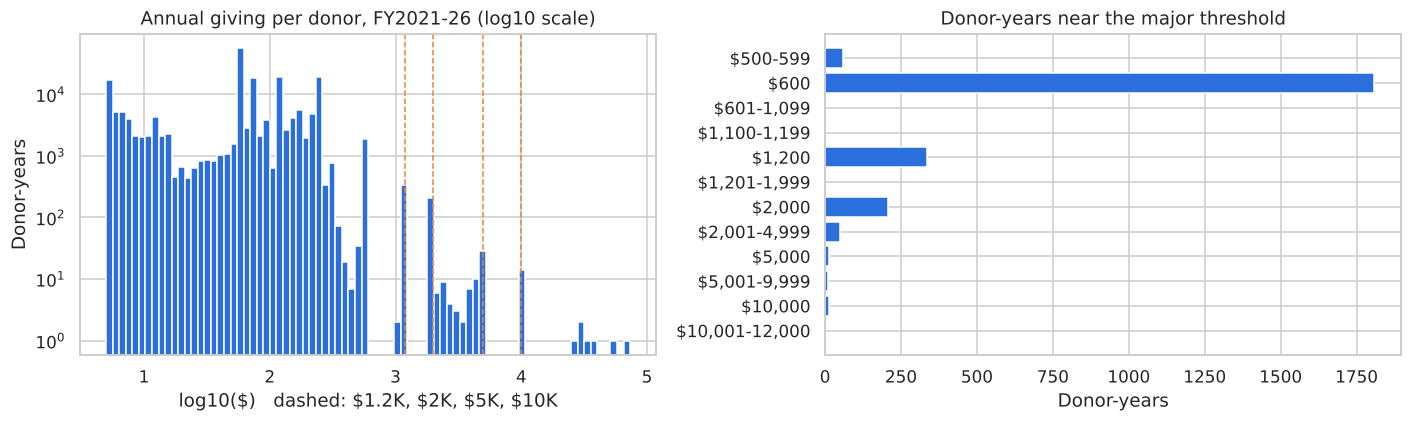

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
g = giving["amount"]
axes[0].hist(np.log10(g), bins=80, color=BLUE)
for tier in [1200, 2000, 5000, 10000]:
    axes[0].axvline(np.log10(tier), color=ORANGE, ls="--", lw=1)
axes[0].set(title="Annual giving per donor, FY2021-26 (log10 scale)", xlabel="log10($)   dashed: $1.2K, $2K, $5K, $10K", ylabel="Donor-years")
axes[0].set_yscale("log")

near = giving[giving["amount"].between(500, 12000)]
bands = pd.cut(near["amount"], [499, 599, 600, 1099, 1199, 1200, 1999, 2000, 4999, 5000, 9999, 10000, 12000],
               labels=["$500-599", "$600", "$601-1,099", "$1,100-1,199", "$1,200", "$1,201-1,999", "$2,000",
                       "$2,001-4,999", "$5,000", "$5,001-9,999", "$10,000", "$10,001-12,000"])
cnt = bands.value_counts().sort_index()
axes[1].barh(cnt.index.astype(str), cnt.values, color=BLUE)
axes[1].invert_yaxis()
axes[1].set(title="Donor-years near the major threshold", xlabel="Donor-years")
plt.tight_layout()
majors = giving[giving["amount"] >= MAJOR]
print(f"Share of major donor-years at exactly $1,200 / $2,000 / $5,000 / $10,000: "
      f"{majors['amount'].isin([1200, 2000, 5000, 10000]).mean():.0%}")
print(f"Major donor-years that include a soft credit: "
      f"{majors.merge(person_soft.rename(columns={'Soft Credit Constituent ID': 'donor_id'})[['donor_id', 'fy']].drop_duplicates(), on=['donor_id', 'fy']).shape[0] / len(majors):.0%}")

**Major giving is rare and lumpy.**
- Only **83–129 donors a year (0.25–0.38%) give $1,200 or more**, and they provide just **5–11% of revenue**. This is well below the "1% of donors, 19% of revenue" figure sometimes quoted in the business case.
- Giving clusters at a few exact amounts. Below the threshold, donors bunch at **$600**. About 90% of major donor-years are **exactly** $1,200, $2,000, $5,000, or $10,000, and almost nobody gives between $600 and $1,200.
- **97% of major donor-years include a soft credit** (a gift paid through a DAF or sponsor).

These patterns look like artifacts of how the synthetic data were generated, so the jump from $600 to $1,200 may be sharper here than in real PBS data.

*Modeling implication:* Conversion is a jump from roughly $600 to a tier amount, not a gradual climb. Predicting a tier ($1,200 / $2,000 / $5,000+) is feasible only coarsely, because few donors reach the higher tiers.

### Building the donor-year panel

For each snapshot year *t* (FY2021–FY2025), the panel holds one row per **eligible** donor: gave in FY *t* and gave less than $1,200. Features use only FY ≤ *t* (Unite years plus legacy history); outcomes use FY *t + 1* onward.

In [15]:
# combined history: legacy household credit (pre-FY2021) + Unite giving (FY2021+)
hist = pd.concat([legacy_wide, wide], axis=1).fillna(0).T.groupby(level=0).sum().T  # donor x FY, FY1984-FY2026
first_fy = hist.gt(0).idxmax(axis=1)

# payment mix and largest single gift per donor-year
mix = person_pay.assign(recurring=person_pay["pledge_gift_type"].eq("Recurring"), upgrade=person_pay["gift_type"].eq("Upgrade")).groupby(["donor_id", "fy"]).agg(
    any_recurring=("recurring", "max"), any_upgrade_gift=("upgrade", "max"))
max_gift = gifts.groupby(["donor_id", "fy"])["amount"].max().rename("max_gift")
soft_years = person_soft.rename(columns={"Soft Credit Constituent ID": "donor_id"})[["donor_id", "fy"]].drop_duplicates()

panel = []
for t in range(2021, 2026):
    d = pd.DataFrame(index=wide.index[(wide[t] > 0) & (wide[t] < MAJOR)])
    d["fy"] = t
    d["amount_t"] = wide.loc[d.index, t]
    h = hist.loc[d.index]
    d["amount_3yr"] = h[[t - 2, t - 1, t]].sum(axis=1)
    d["years_gave_last5"] = (h[[t - 4, t - 3, t - 2, t - 1, t]] > 0).sum(axis=1)
    d["tenure_years"] = t - first_fy.loc[d.index]
    d["former_major"] = (h[[c for c in h.columns if c < t]] >= MAJOR).any(axis=1)
    d["amount_next"] = wide.loc[d.index, t + 1]
    future = [c for c in wide.columns if c > t]
    d["conv_12m"] = d["amount_next"] >= MAJOR
    d["conv_3yr"] = (wide.loc[d.index, future[:3]] >= MAJOR).any(axis=1) if len(future) >= 3 else np.nan
    d["conv_5yr"] = (wide.loc[d.index, future[:5]] >= MAJOR).any(axis=1) if len(future) >= 5 else np.nan
    d["retained"] = d["amount_next"] > 0
    panel.append(d.reset_index())
panel = pd.concat(panel, ignore_index=True)
panel = panel.merge(mix.reset_index(), on=["donor_id", "fy"], how="left").merge(max_gift.reset_index(), on=["donor_id", "fy"], how="left")
panel[["any_recurring", "any_upgrade_gift"]] = panel[["any_recurring", "any_upgrade_gift"]].fillna(False).astype(bool)
panel["soft_credit_t"] = panel.set_index(["donor_id", "fy"]).index.isin(soft_years.set_index(["donor_id", "fy"]).index)
prior_soft = soft_years.groupby("donor_id")["fy"].min()
panel["soft_credit_ever"] = panel["fy"] >= panel["donor_id"].map(prior_soft).fillna(9999)
panel["donor_type"] = np.where(panel["any_recurring"], "Recurring (sustainer)", "One-time only")
print(f"Panel: {len(panel):,} eligible donor-years, {panel['donor_id'].nunique():,} donors")
panel[["amount_t", "amount_3yr", "years_gave_last5", "tenure_years", "max_gift", "amount_next"]].describe()

Panel: 160,919 eligible donor-years, 60,556 donors


,amount_t,amount_3yr,years_gave_last5,tenure_years,max_gift,amount_next
count,"160,919.00","160,919.00","160,919.00","160,919.00","160,919.00","160,919.00"
mean,89.00,225.78,3.06,8.23,24.54,79.16
std,88.13,335.19,1.56,8.47,58.07,290.17
min,5.00,5.00,1.00,0.00,2.00,0.00
25%,23.00,60.00,2.00,1.00,5.00,5.00
50%,60.00,180.00,3.00,4.00,8.00,60.00
75%,120.00,288.00,5.00,16.00,15.00,120.00
max,"1,080.00","35,193.00",5.00,41.00,600.00,"73,360.00"


### Conversion base rates

In [16]:
def rates(col, years):
    sub = panel[panel["fy"].isin(years)]
    return pd.Series({
        "snapshot years": f"FY{min(years)}-{max(years)}" if len(years) > 1 else f"FY{years[0]}",
        "eligible donor-years": len(sub),
        "converters": int(sub[col].sum()),
        "conversion rate": sub[col].mean(),
        "rate, never-major": sub.loc[~sub["former_major"], col].mean(),
        "rate, former major": sub.loc[sub["former_major"], col].mean(),
        "share of converters who were former majors": sub.loc[sub[col].astype(bool), "former_major"].mean(),
    })

base = pd.DataFrame({
    "12 months": rates("conv_12m", list(range(2021, 2026))),
    "within 3 years": rates("conv_3yr", [2021, 2022, 2023]),
    "within 5 years": rates("conv_5yr", [2021]),
}).T
base.style.format({"eligible donor-years": "{:,}", "converters": "{:,}", "conversion rate": "{:.3%}", "rate, never-major": "{:.3%}",
                   "rate, former major": "{:.2%}", "share of converters who were former majors": "{:.0%}"})

,snapshot years,eligible donor-years,converters,conversion rate,"rate, never-major","rate, former major",share of converters who were former majors
12 months,FY2021-2025,"160,919",269,0.167%,0.082%,14.33%,51%
within 3 years,FY2021-2023,"95,249",343,0.360%,0.206%,27.41%,43%
within 5 years,FY2021,"30,843",169,0.548%,0.359%,35.12%,35%


,eligible,converters,rate
FY2021 -> FY2022,"30,843",55,0.178%
FY2022 -> FY2023,"31,198",53,0.170%
FY2023 -> FY2024,"33,208",37,0.111%
FY2024 -> FY2025,"32,784",44,0.134%
FY2025 -> FY2026,"32,886",80,0.243%


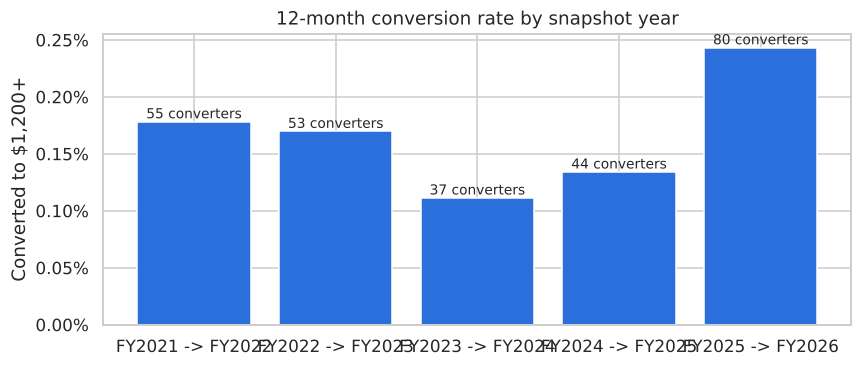

In [17]:
yr = panel.groupby("fy").agg(eligible=("conv_12m", "size"), converters=("conv_12m", "sum"), rate=("conv_12m", "mean"))
yr.index = [f"FY{t} -> FY{t + 1}" for t in yr.index]
fig, ax = plt.subplots(figsize=(8, 3.5))
ax.bar(yr.index, yr["rate"], color=BLUE)
ax.yaxis.set_major_formatter(mtick.PercentFormatter(1, decimals=2))
for i, (r, n) in enumerate(zip(yr["rate"], yr["converters"])):
    ax.text(i, r, f"{n} converters", ha="center", va="bottom", fontsize=9)
ax.set(title="12-month conversion rate by snapshot year", ylabel="Converted to $1,200+")
plt.tight_layout()
yr.style.format({"eligible": "{:,}", "converters": "{:,}", "rate": "{:.3%}"})

**Conversion base rates**
- **12 months: 0.17%**, or 269 converters across five snapshot years (about 54 a year among about 32,000 eligible donors).
- **Within 3 years: 0.36%.**
- **Within 5 years: 0.55%.** Only one snapshot (FY2021) has five future years, so this rate is the least reliable.
- **Former major donors** (donors who gave $1,200+ in any earlier year, including legacy history) are only 0.6% of eligible donor-years but **51% of 12-month converters**. They convert at 14% a year, against 0.08% for never-major donors.
- **FY2025 → FY2026 has the highest rate (0.24%, 80 converters)**, consistent with the FY2026 influx.

*Modeling implications:*
- Former majors are mostly lapsed donors that staff already know. Results should be reported **separately for never-major donors**, where a model would add the most value.
- With about 50 positive cases per year, use rare-event metrics (precision, recall, and lift at K; PR-AUC) and validate by time.

### Context: year-to-year movement between giving bands

Most donors stay in their band. The matrix shows where FY2025 donors (all donors, not just eligible ones) landed in FY2026.

from
$1-50          5
$51-100        3
$101-250      23
$251-599       6
$600-1,199    43
$1,200+       41


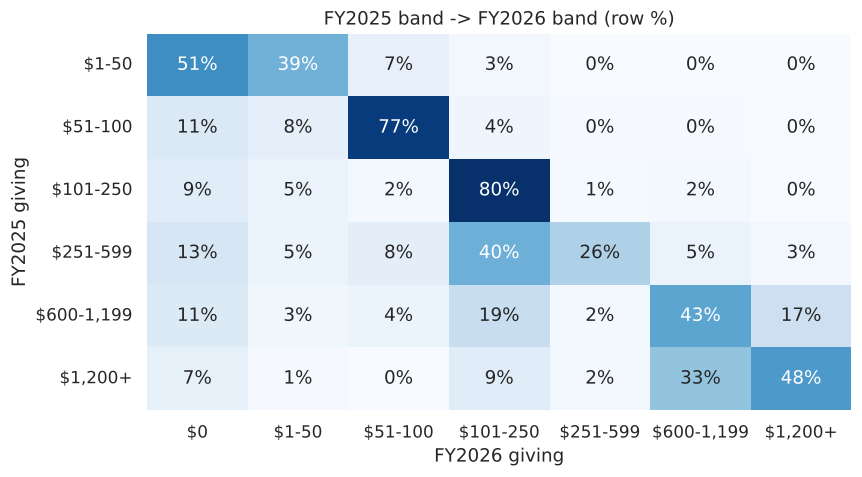

In [18]:
bands_ = [-np.inf, 0, 50, 100, 250, 599, 1199, np.inf]
labels_ = ["$0", "$1-50", "$51-100", "$101-250", "$251-599", "$600-1,199", "$1,200+"]
trans = pd.DataFrame({"from": pd.cut(wide[2025], bands_, labels=labels_), "to": pd.cut(wide[2026], bands_, labels=labels_)})
trans = trans[trans["from"] != "$0"]
mat = pd.crosstab(trans["from"], trans["to"], normalize="index")
fig, ax = plt.subplots(figsize=(8, 4.5))
sns.heatmap(mat, annot=True, fmt=".0%", cmap="Blues", cbar=False, ax=ax)
ax.set(title="FY2025 band -> FY2026 band (row %)", xlabel="FY2026 giving", ylabel="FY2025 giving")
plt.tight_layout()
print(pd.crosstab(trans["from"], trans["to"]).loc[:, "$1,200+"].rename("FY2026 major donors coming from each FY2025 band").to_string())

Most donors stay in their band from year to year. FY2026's new major donors come mainly from the **$600–1,199 band (43)** and from donors who were already major (41); smaller groups come from lower bands.

## 7. Giving history as predictors

Each chart shows the 12-month conversion rate by feature level (FY2021–FY2025 snapshots pooled) and the **lift** over the overall rate. With so few converters, small groups are noisy, so counts are shown.

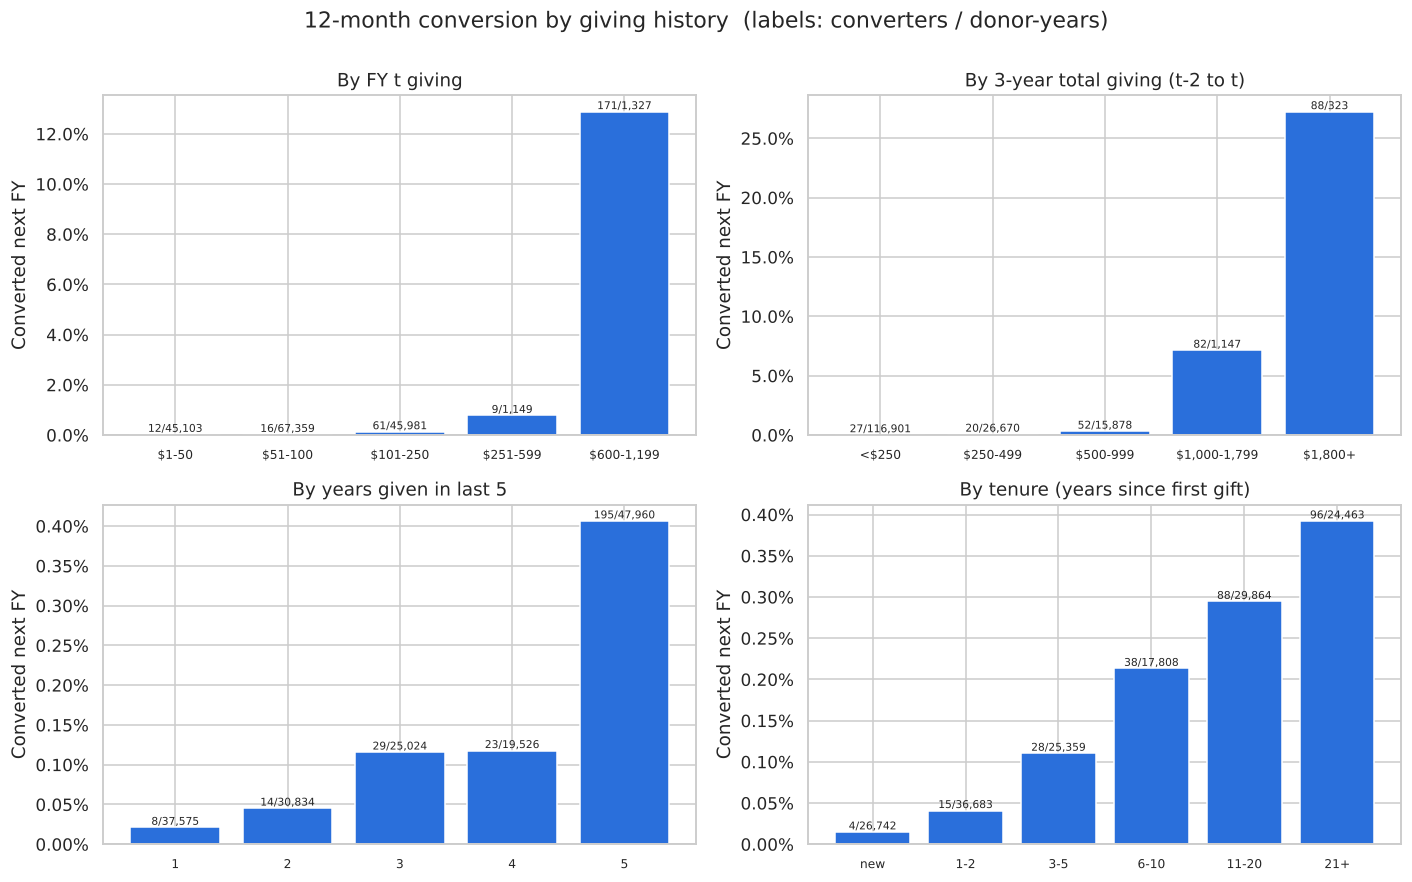

In [19]:
overall = panel["conv_12m"].mean()


def conv_table(col, data=None, order=None):
    data = panel if data is None else data
    r = data.groupby(col, observed=True).agg(donor_years=("conv_12m", "size"), converters=("conv_12m", "sum"), rate=("conv_12m", "mean"))
    if order is not None:
        r = r.reindex(order)
    r["lift"] = r["rate"] / overall
    return r


def conv_plot(ax, col, title, data=None, order=None):
    r = conv_table(col, data, order)
    ax.bar(r.index.astype(str), r["rate"], color=BLUE)
    ax.yaxis.set_major_formatter(mtick.PercentFormatter(1, decimals=2 if r["rate"].max() < 0.01 else 1))
    ax.set(title=title, ylabel="Converted next FY")
    ax.tick_params(axis="x", labelsize=8)
    for i, (v, c, n) in enumerate(zip(r["rate"], r["converters"], r["donor_years"])):
        ax.text(i, v, f"{c:,}/{n:,}", ha="center", va="bottom", fontsize=7)
    return r


panel["giving_band"] = pd.cut(panel["amount_t"], [0, 50, 100, 250, 599, 1199], labels=["$1-50", "$51-100", "$101-250", "$251-599", "$600-1,199"])
panel["three_yr_band"] = pd.cut(panel["amount_3yr"], [0, 250, 500, 1000, 1800, 1e9], labels=["<$250", "$250-499", "$500-999", "$1,000-1,799", "$1,800+"])
panel["tenure_band"] = pd.cut(panel["tenure_years"], [-1, 0, 2, 5, 10, 20, 50], labels=["new", "1-2", "3-5", "6-10", "11-20", "21+"])

fig, axes = plt.subplots(2, 2, figsize=(13, 8))
conv_plot(axes[0, 0], "giving_band", "By FY t giving")
conv_plot(axes[0, 1], "three_yr_band", "By 3-year total giving (t-2 to t)")
conv_plot(axes[1, 0], "years_gave_last5", "By years given in last 5")
conv_plot(axes[1, 1], "tenure_band", "By tenure (years since first gift)")
fig.suptitle("12-month conversion by giving history  (labels: converters / donor-years)", y=1.0)
plt.tight_layout()

,share of donor-years,rate if yes,rate if no,converters if yes,lift if yes
Former major donor,0.6%,14.33%,0.082%,138.0,85.7x
Soft credit (DAF / sponsor) in FY t,1.7%,3.32%,0.114%,89.0,19.9x
Any soft credit up to FY t,3.4%,2.78%,0.074%,154.0,16.6x
Upgrade gift in FY t,2.1%,1.48%,0.138%,51.0,8.9x
Recurring (sustainer) in FY t,65.2%,0.11%,0.272%,117.0,0.7x


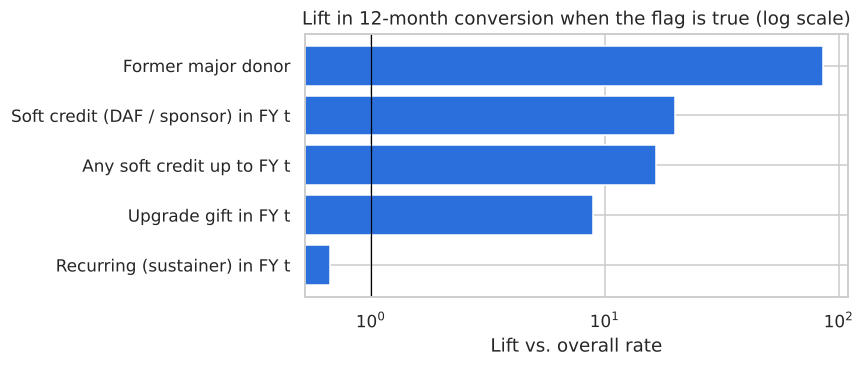

In [20]:
flags = {
    "Former major donor": "former_major",
    "Soft credit (DAF / sponsor) in FY t": "soft_credit_t",
    "Any soft credit up to FY t": "soft_credit_ever",
    "Upgrade gift in FY t": "any_upgrade_gift",
    "Recurring (sustainer) in FY t": "any_recurring",
}
flag_tab = pd.DataFrame({
    label: {
        "share of donor-years": panel[col].mean(),
        "rate if yes": panel.loc[panel[col], "conv_12m"].mean(),
        "rate if no": panel.loc[~panel[col], "conv_12m"].mean(),
        "converters if yes": int(panel.loc[panel[col], "conv_12m"].sum()),
    }
    for label, col in flags.items()
}).T
flag_tab["lift if yes"] = flag_tab["rate if yes"] / overall

fig, ax = plt.subplots(figsize=(8, 3.5))
ax.barh(flag_tab.index, flag_tab["lift if yes"], color=BLUE)
ax.axvline(1, color="black", lw=0.8)
ax.set_xscale("log")
ax.invert_yaxis()
ax.set(title="Lift in 12-month conversion when the flag is true (log scale)", xlabel="Lift vs. overall rate")
plt.tight_layout()
flag_tab.style.format({"share of donor-years": "{:.1%}", "rate if yes": "{:.2%}", "rate if no": "{:.3%}", "converters if yes": "{:,}", "lift if yes": "{:.1f}x"})

In [21]:
# sustainers renew far more often but convert less: the two outcomes behave differently
both = panel.groupby("donor_type").agg(donor_years=("conv_12m", "size"), gave_again=("retained", "mean"),
                                       converted=("conv_12m", "mean"), median_giving_t=("amount_t", "median"))
both.style.format({"donor_years": "{:,}", "gave_again": "{:.1%}", "converted": "{:.3%}", "median_giving_t": "${:,.0f}"})

,donor_years,gave_again,converted,median_giving_t
donor_type,,,,
One-time only,"55,943",51.4%,0.272%,$9
Recurring (sustainer),"104,976",92.1%,0.111%,$72


In [22]:
# among never-major donors only (the group staff are least likely to know already)
nm = panel[~panel["former_major"]]
conv_table("giving_band", nm).style.format({"donor_years": "{:,}", "converters": "{:,}", "rate": "{:.3%}", "lift": "{:.1f}x"})

,donor_years,converters,rate,lift
giving_band,,,,
$1-50,"44,924",11,0.024%,0.1x
$51-100,"67,241",15,0.022%,0.1x
$101-250,"45,677",41,0.090%,0.5x
$251-599,"1,119",7,0.626%,3.7x
"$600-1,199",995,57,5.729%,34.3x


**Giving history is the strongest signal.**
- **Prior-year giving:** the $600–1,199 band (essentially donors giving exactly $600) converts at about **13%**, roughly **75× the overall rate**, and holds about two thirds of all converters. Below $600, conversion is near zero.
- **Three-year total:** conversion climbs steeply, from 7% at $1,000–1,799 to 27% at $1,800 or more. Donors at $1,800+ have often been major before.
- **Consistency and tenure:** donors who gave in all of the last five years, or who have given for 21+ years, convert at about 0.4%. That is low in absolute terms but roughly 20× the donors with the shortest history.
- **Flags:** **former major** (86× lift), a **soft credit in FY *t*** (20×), and an **upgrade gift in FY *t*** (9×) are strong signals.
- **Sustainers move the other way.** They give again 92% of the time (one-time donors: 51%), but they **convert less often** (0.11% vs. 0.27%). Sustainers are a steady, mid-level base, while conversions come from one-time donors who give large single gifts.
- **Never-major donors:** the $600 band still stands out, at 5.7% (34× lift).

*Modeling implication:* Build features for prior-year amount, three-year total, max gift, former-major flag, soft-credit/DAF flag, upgrade flag, recurring flag, years given in the last five, and tenure (including legacy history). The jump at $600 means tree-based models, or explicit threshold features, will fit better than linear terms in raw dollars.

## 8. Constituent attributes and leakage

The constituents table describes each person **as of the end of the data (FY2026)**. Some fields are stable (gender, state). Others are **snapshots** that would leak future information if used as features for earlier years.

In [23]:
people = con[con["Primary Constituent Type"] != "Organization"].copy()
fy26 = wide[2026].reindex(people["Constituent ID"]).fillna(0).values
people["FY2026 giving"] = pd.cut(fy26, [-1, 0, 599, 1199, np.inf], labels=["$0", "$1-599", "$600-1,199", "$1,200+"])
for col in ["Annual Giving Group", "Sustainer PBS Utah", "Major Donor Class PBS Utah"]:
    people[col] = people[col].fillna("(blank)")
leak = {col: pd.crosstab(people[col], people["FY2026 giving"]) for col in ["Annual Giving Group", "Major Donor Class PBS Utah", "Sustainer PBS Utah"]}
pd.concat(leak, names=["field", "value"])

FY2026 giving                               $0  $1-599  $600-1,199  $1,200+
field                      value                                           
Annual Giving Group        CD                0       0           0      129
                           LD                0    2600           0        0
                           ND           157815       0           0        0
                           PD                0   35139           0        0
                           SL                0       0         482        0
Major Donor Class PBS Utah (blank)      157595   37600         411        0
                           Broadcaster       0       0           0       63
                           Director          0       0           0       66
                           Former          220     139          71        0
Sustainer PBS Utah         False        157815   10752         201       89
                           True              0   26987         281       40

In [24]:
u = people.set_index("Constituent ID")
fy25 = wide[2025].reindex(u.index).fillna(0)
print(f"Previous FY UofU Cash > 0 exactly when the person gave to PBS in FY2025: "
      f"{((u['Previous FY UofU Cash'] > 0) == (fy25 > 0)).mean():.1%} agreement")
print(f"Spearman corr, Lifetime UofU Fundraising vs. PBS giving FY2021-26: "
      f"{u['Lifetime UofU Fundraising'].corr(wide.sum(axis=1).reindex(u.index).fillna(0), method='spearman'):.2f}")

Previous FY UofU Cash > 0 exactly when the person gave to PBS in FY2025: 100.0% agreement
Spearman corr, Lifetime UofU Fundraising vs. PBS giving FY2021-26: 0.54


**Several snapshot fields are effectively the FY2026 outcome:**
- `Annual Giving Group` maps exactly onto FY2026 giving: ND = no FY2026 gift, and CD = $1,200+.
- `Major Donor Class` = Broadcaster or Director only for FY2026 major donors.
- The sustainer flag is only ever true for FY2026 givers.
- `Previous FY UofU Cash` is positive **exactly** when the person gave to PBS in FY2025, and `Lifetime UofU Fundraising` tracks PBS giving.

These fields describe donors at the end of the data, so using them as features for earlier years would leak the outcome. **Exclude them all.** Recurring status is rebuilt from each year's payments instead, and age is rolled back to the snapshot year (`Age − (2026 − t)`).

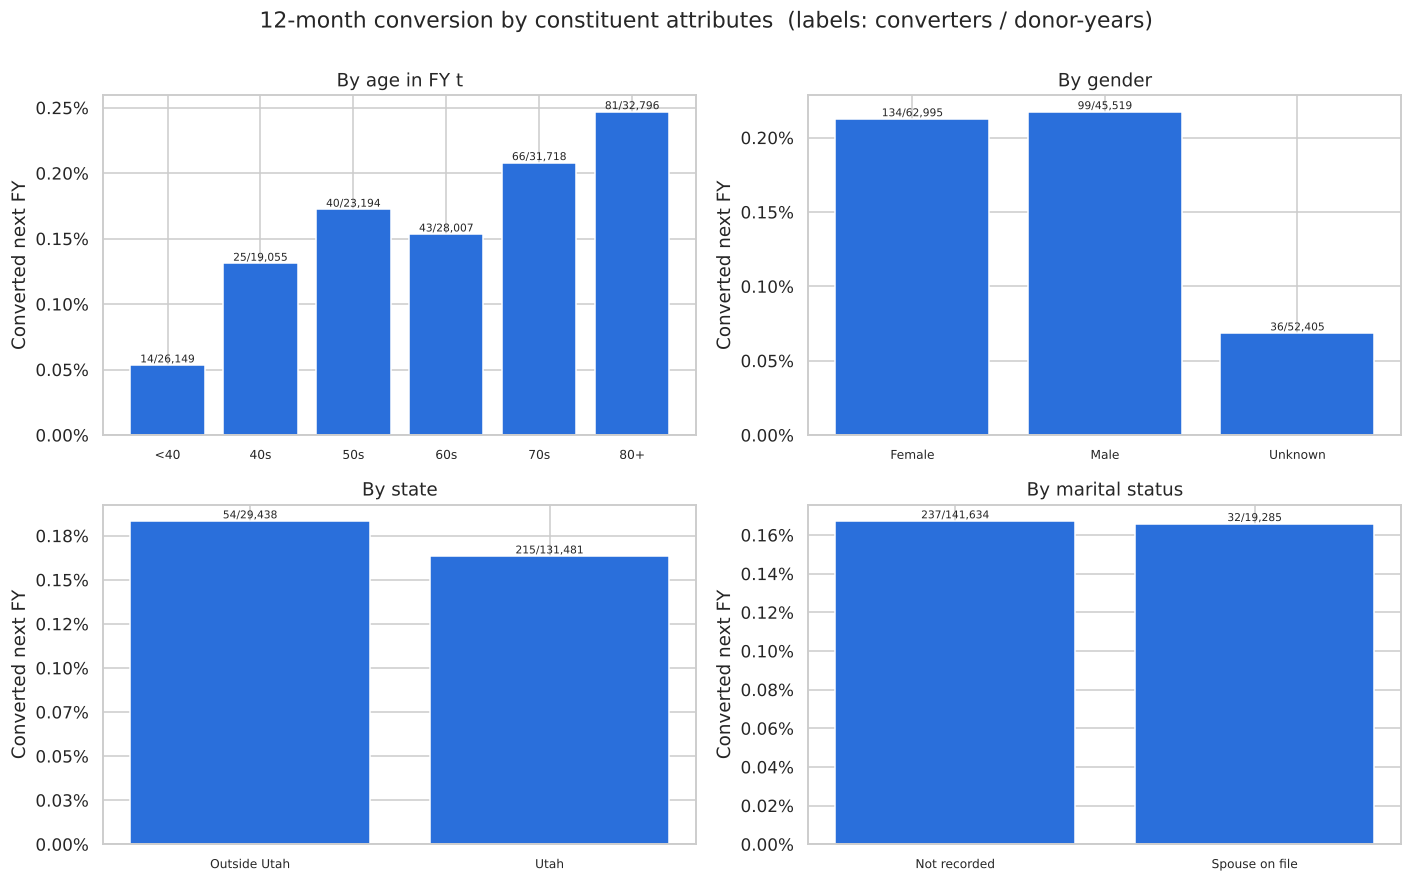

In [25]:
attr = panel.merge(
    people[["Constituent ID", "Age", "Gender", "Address State", "Marital Status"]],
    left_on="donor_id", right_on="Constituent ID", how="left",
)
attr["age_at_t"] = attr["Age"] - (2026 - attr["fy"])  # age is a FY2026 snapshot, so back it out
attr["age_band"] = pd.cut(attr["age_at_t"], [0, 40, 50, 60, 70, 80, 120], labels=["<40", "40s", "50s", "60s", "70s", "80+"])
attr["utah"] = np.where(attr["Address State"] == "UT", "Utah", "Outside Utah")
attr["married"] = np.where(attr["Marital Status"] == "Married", "Spouse on file", "Not recorded")

fig, axes = plt.subplots(2, 2, figsize=(13, 8))
conv_plot(axes[0, 0], "age_band", "By age in FY t", data=attr)
conv_plot(axes[0, 1], "Gender", "By gender", data=attr)
conv_plot(axes[1, 0], "utah", "By state", data=attr)
conv_plot(axes[1, 1], "married", "By marital status", data=attr)
fig.suptitle("12-month conversion by constituent attributes  (labels: converters / donor-years)", y=1.0)
plt.tight_layout()

**Demographics carry a modest signal.**
- Conversion rises with **age**, from 0.05% under 40 to 0.25% at 80+. Part of this overlaps with tenure: older donors have given longer.
- **"Unknown" gender** converts at a third of the rate of known gender (0.07% vs. 0.21–0.22%). That probably reflects record completeness rather than gender itself.
- State and spouse-on-file make little difference.

Age is usable after the roll-back. Gender and geography are better used to audit the model's coverage and fairness than as predictors.

## 9. Solicitations

`campaign_members` records every solicitation (FY2021–FY2026) and whether the person paid on the same marketing code that fiscal year. `campaign_start_date` is a fiscal-year marker, not a contact date.

In [26]:
by_year = members.groupby("fy").agg(solicitations=("responded", "size"), people=("constituent_id", "nunique"), response_rate=("responded", "mean"))
by_year["solicitations per person"] = by_year["solicitations"] / by_year["people"]
by_year.style.format({"solicitations": "{:,}", "people": "{:,}", "response_rate": "{:.2%}", "solicitations per person": "{:.1f}"})

,solicitations,people,response_rate,solicitations per person
fy,,,,
2021,"504,933","41,992",2.10%,12.0
2022,"675,165","58,675",1.65%,11.5
2023,"969,988","90,433",1.23%,10.7
2024,"1,065,866","100,658",1.14%,10.6
2025,"892,825","80,102",1.37%,11.1
2026,"1,124,627","101,978",1.30%,11.0


responded_t,No response in FY t,Responded in FY t
giving_band,,
$1-50,0.03%,0.02%
$51-100,0.02%,0.02%
$101-250,0.10%,0.19%
$251-599,0.78%,0.78%
"$600-1,199",13.68%,12.03%


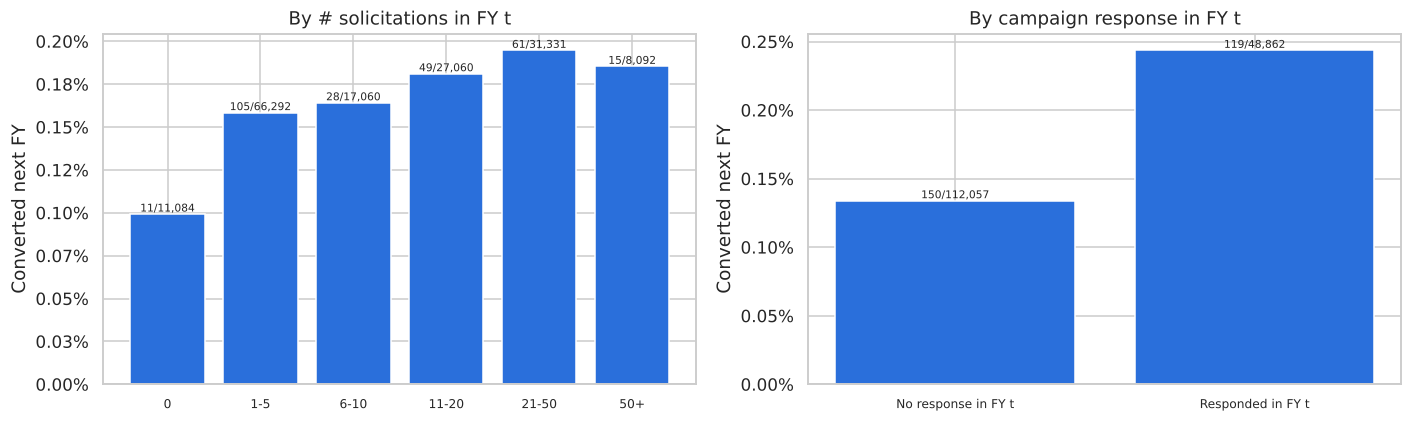

In [27]:
sol = members.groupby(["constituent_id", "fy"], observed=True).agg(n_solicited=("responded", "size"), n_responded=("responded", "sum")).reset_index()
sol["constituent_id"] = sol["constituent_id"].astype(str)
panel = panel.merge(sol, left_on=["donor_id", "fy"], right_on=["constituent_id", "fy"], how="left").drop(columns="constituent_id")
panel[["n_solicited", "n_responded"]] = panel[["n_solicited", "n_responded"]].fillna(0)
panel["solicited_band"] = pd.cut(panel["n_solicited"], [-1, 0, 5, 10, 20, 50, 1000], labels=["0", "1-5", "6-10", "11-20", "21-50", "50+"])
panel["responded_t"] = np.where(panel["n_responded"] > 0, "Responded in FY t", "No response in FY t")

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
conv_plot(axes[0], "solicited_band", "By # solicitations in FY t")
conv_plot(axes[1], "responded_t", "By campaign response in FY t")
plt.tight_layout()

# does response add anything once FY t giving is known?
panel.groupby(["giving_band", "responded_t"], observed=True)["conv_12m"].mean().unstack().style.format("{:.2%}")

**Solicitations do not add information beyond giving.**
- Roughly 0.5–1.1 million solicitations go out each year, about 11 per person solicited. Same-code response rates fell from 2.1% to about 1.3%.
- Conversion differs across solicitation-count bands, but within each giving band, donors who responded to a campaign in FY *t* convert at about the same rate as those who didn't (e.g., 12% vs. 14% in the $600–1,199 band).

Who gets solicited is decided by PBS based on giving status, so this table cannot show whether solicitation *causes* giving. Solicitation features are weak candidates.

## 10. Passport viewing

The table only has rows for constituent-years with viewing; a missing year could mean no account, no consent, or no viewing.

Spearman corr, titles viewed vs FY t giving (viewers only): 0.01


viewed,No record,Viewed
giving_band,,
$1-50,0.03%,0.03%
$51-100,0.01%,0.03%
$101-250,0.16%,0.10%
$251-599,0.61%,1.20%
"$600-1,199",13.14%,12.32%


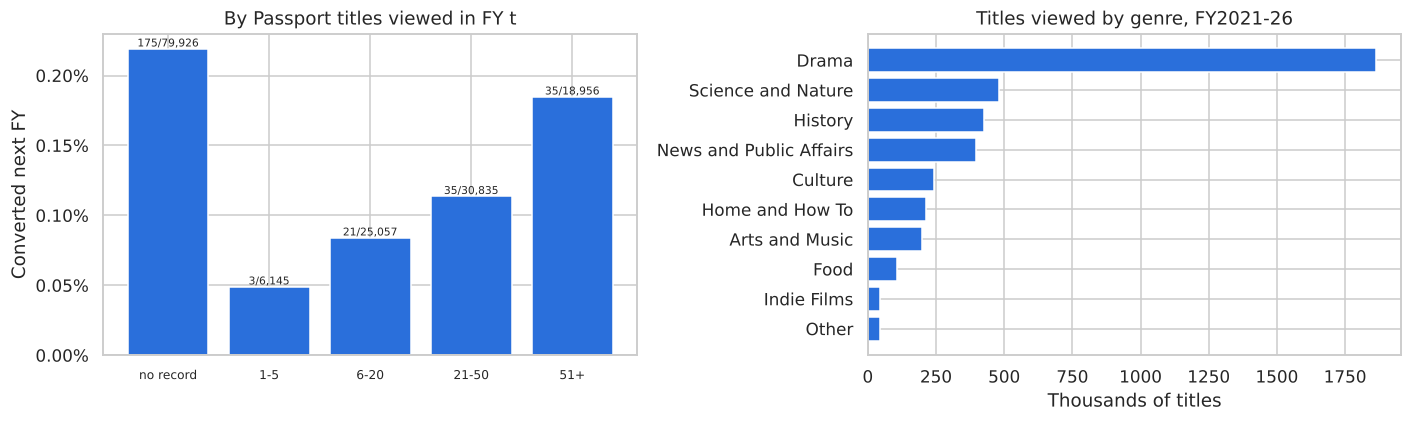

In [28]:
pv = passport.groupby(["constituent_id", "fiscal_year"]).agg(titles=("titles_viewed", "sum"), genres=("genre", "nunique")).reset_index()
panel = panel.merge(pv, left_on=["donor_id", "fy"], right_on=["constituent_id", "fiscal_year"], how="left").drop(columns=["constituent_id", "fiscal_year"])
panel["titles_band"] = pd.cut(panel["titles"].fillna(0), [-1, 0, 5, 20, 50, 10_000], labels=["no record", "1-5", "6-20", "21-50", "51+"])

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
conv_plot(axes[0], "titles_band", "By Passport titles viewed in FY t")
gp = passport.groupby("genre")["titles_viewed"].sum().sort_values()
axes[1].barh(gp.index, gp.values / 1e3, color=BLUE)
axes[1].set(title="Titles viewed by genre, FY2021-26", xlabel="Thousands of titles")
plt.tight_layout()

viewed = panel["titles"].notna()
print(f"Spearman corr, titles viewed vs FY t giving (viewers only): {panel.loc[viewed, 'titles'].corr(panel.loc[viewed, 'amount_t'], method='spearman'):.2f}")
panel.assign(viewed=np.where(viewed, "Viewed", "No record")).groupby(["giving_band", "viewed"], observed=True)["conv_12m"].mean().unstack().style.format("{:.2%}")

**Passport viewing shows no useful association.**
- Titles viewed are essentially unrelated to giving (Spearman ρ = 0.01 among viewers).
- Within each giving band, viewers and non-viewers convert at similar rates. The one apparent gap ($251–599 band) rests on a handful of converters.

A year with no viewing rows can mean no account, no consent, or no viewing. Treat it as "no record", not as zero, if Passport is kept at all.

## 11. The cultivation program

Each year from FY2022 to FY2025, eight officer portfolios each **selected** 125 donors (1,000 per year). Within each portfolio, about a quarter of selected donors were **randomly held out** from contact. Portfolios **adopted** the cultivation program in a staggered rollout (FY2023–FY2026, one never). The random holdout makes contacted vs. holdout a fair comparison.

In [29]:
print(portfolios.astype({"rollout_fy": "Int64"}).to_string(index=False))
pd.crosstab([cult["fiscal_year"], cult["program_adopted"]], cult["contacted"], margins=True).rename(columns={False: "holdout", True: "contacted"})

portfolio_id officer_id  capacity  rollout_fy
         P01 OFFICER-01       125        2023
         P02 OFFICER-02       125        2023
         P03 OFFICER-03       125        2024
         P04 OFFICER-04       125        2024
         P05 OFFICER-05       125        2025
         P06 OFFICER-06       125        2025
         P07 OFFICER-07       125        2026
         P08 OFFICER-08       125        <NA>


contacted                    holdout  contacted   All
fiscal_year program_adopted                          
2022        False                248        752  1000
2023        False                186        564   750
            True                  62        188   250
2024        False                124        376   500
            True                 124        376   500
2025        False                 62        188   250
            True                 186        564   750
All                              992       3008  4000

In [30]:
def amt(donor, year):
    return wide.at[donor, year] if (donor in wide.index and year in wide.columns) else 0.0

c = cult.copy()
c["giving_prior"] = [amt(d, y - 1) for d, y in zip(c["synthetic_id"], c["fiscal_year"])]
c["giving_next"] = [amt(d, y + 1) for d, y in zip(c["synthetic_id"], c["fiscal_year"])]
CAP = 2000  # cap each year's giving (~99th percentile) so a few five-figure gifts don't swamp the means
c["change_capped"] = c["giving_next"].clip(upper=CAP) - c["giving_prior"].clip(upper=CAP)
c["converted_next"] = c["giving_next"] >= MAJOR
c["group"] = np.where(c["contacted"], "Contacted", "Holdout")
c["program"] = np.where(c["program_adopted"], "After adoption", "Before adoption")
c["has_soft_credit"] = c["synthetic_id"].isin(person_soft["Soft Credit Constituent ID"])

sel_vs_pop = pd.DataFrame({
    "selected donors": c.groupby("fiscal_year")["giving_prior"].median(),
    "all donors": giving.assign(fiscal_year=giving["fy"] + 1).groupby("fiscal_year")["amount"].median(),
}).loc[2022:2025]
print("Median giving in the year before selection:")
print(sel_vs_pop)
print(f"\nSelected donors with any soft credit: {c['has_soft_credit'].mean():.0%} vs. "
      f"{wide.index.isin(person_soft['Soft Credit Constituent ID']).mean():.0%} of all donors")
print(f"Selected donors who were already major in the prior year: {(c['giving_prior'] >= MAJOR).mean():.1%}\n")

# conversion: selected donors below $1,200 in the year before selection
cc = c[c["giving_prior"] < MAJOR]
res = cc.groupby(["program", "group"]).agg(
    n=("converted_next", "size"), converted=("converted_next", "sum"), conv_rate=("converted_next", "mean"),
    conv_se=("converted_next", "sem"), change=("change_capped", "mean"), change_se=("change_capped", "sem"),
)
res.style.format({"n": "{:,}", "converted": "{:,}", "conv_rate": "{:.2%}", "conv_se": "{:.2%}", "change": "${:,.1f}", "change_se": "${:,.1f}"})

Median giving in the year before selection:
             selected donors  all donors
fiscal_year                             
2022                  120.00       60.00
2023                  120.00       60.00
2024                  120.00       60.00
2025                  120.00       60.00

Selected donors with any soft credit: 33% vs. 4% of all donors
Selected donors who were already major in the prior year: 3.0%



,conversion difference,conv. std. error,$ change difference (capped),$ std. error
program,,,,
After adoption,+3.59%,1.00%,$+59.2,$15.8
Before adoption,+0.85%,0.64%,$+7.5,$11.6


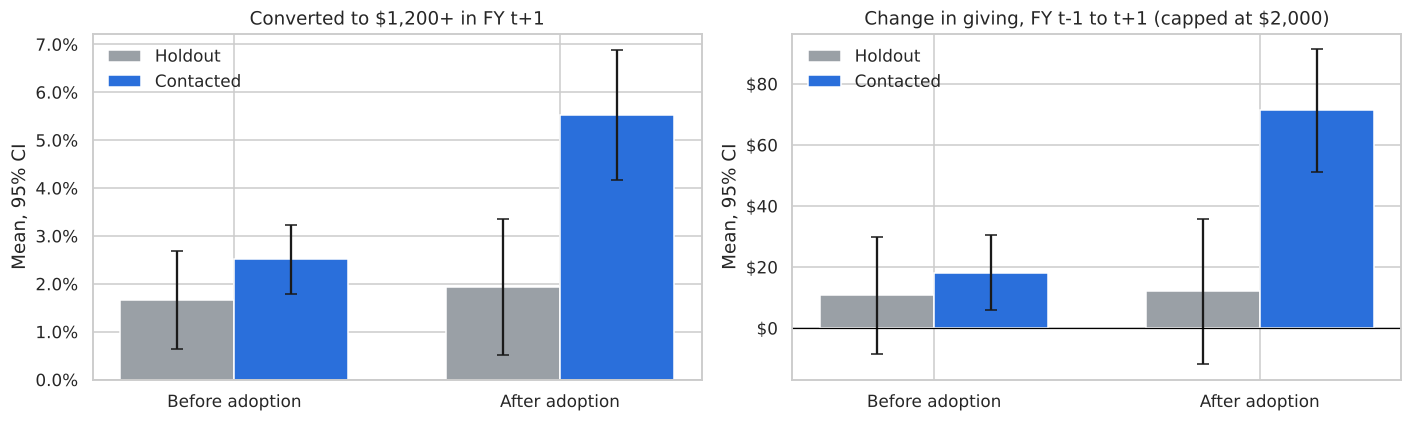

In [31]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
x = np.arange(2)
for j, (col, se, title, fmt) in enumerate([
    ("conv_rate", "conv_se", "Converted to $1,200+ in FY t+1", mtick.PercentFormatter(1)),
    ("change", "change_se", "Change in giving, FY t-1 to t+1 (capped at $2,000)", mtick.StrMethodFormatter("${x:,.0f}")),
]):
    ax = axes[j]
    for i, grp in enumerate(["Holdout", "Contacted"]):
        r = res.xs(grp, level="group").reindex(["Before adoption", "After adoption"])
        ax.bar(x + (i - 0.5) * 0.35, r[col], 0.35, yerr=1.96 * r[se], capsize=4, color=[GREY, BLUE][i], label=grp)
    ax.axhline(0, color="black", lw=0.8)
    ax.set_xticks(x, ["Before adoption", "After adoption"])
    ax.yaxis.set_major_formatter(fmt)
    ax.set(title=title, ylabel="Mean, 95% CI")
    ax.legend(frameon=False)
plt.tight_layout()

con_, hold = res.xs("Contacted", level="group"), res.xs("Holdout", level="group")
eff = pd.DataFrame({
    "conversion difference": con_["conv_rate"] - hold["conv_rate"],
    "conv. std. error": np.sqrt(con_["conv_se"] ** 2 + hold["conv_se"] ** 2),
    "$ change difference (capped)": con_["change"] - hold["change"],
    "$ std. error": np.sqrt(con_["change_se"] ** 2 + hold["change_se"] ** 2),
})
eff.style.format({"conversion difference": "{:+.2%}", "conv. std. error": "{:.2%}", "$ change difference (capped)": "${:+,.1f}", "$ std. error": "${:,.1f}"})

In [32]:
# how many future major donors had been selected for cultivation the year before?
new_major = giving[(giving["amount"] >= MAJOR) & giving["fy"].between(2023, 2026)]
sel_prev = cult.assign(fy=cult["fiscal_year"] + 1)[["synthetic_id", "fy"]].rename(columns={"synthetic_id": "donor_id"})
was_sel = new_major.merge(sel_prev, on=["donor_id", "fy"], how="left", indicator=True)["_merge"].eq("both").mean()
print(f"Major donor-years FY2023-26 whose donor was selected for cultivation the year before: {was_sel:.0%}")

Major donor-years FY2023-26 whose donor was selected for cultivation the year before: 42%


**Cultivation findings.**
- **Selection is not random.** Officers pick donors whose median prior-year giving is $120, twice the typical donor's $60. A third of selected donors have a soft credit, against 4% of all donors. **The random holdout is what makes contacted vs. holdout a fair comparison.**
- **Before a portfolio adopts the program**, contact makes little difference: conversion is +0.9 points (SE 0.6), and capped giving change is +$8 (SE $12).
- **After adoption**, contacted donors convert to $1,200+ at **5.5% vs. 1.9%** for holdouts, a gain of **+3.6 points (SE 1.0)**, nearly triple. Capped giving change is **+$59 (SE $16)**.
- **42% of major donor-years in FY2023–26** belonged to donors selected for cultivation the year before.

*Modeling implications:*
- Contact *causes* some conversions. A model trained on outcomes that already include officer contact partly learns "who staff chose" rather than donor potential. Cultivation fields should therefore be **excluded from (or controlled for in) the baseline model**.
- The effect suggests a second question worth modeling: for whom does contact make the biggest difference (**uplift**). With 992 holdout donor-years, that can only be explored coarsely.

## 12. Simple ranking baselines

Before building a model, it is worth knowing how well simple rules already rank donors. For each snapshot year, the eligible donors are ranked by a rule, and the top **K = 1,000** (the program's annual capacity) are compared with who actually converted the next year. Ties (common, because many donors give exactly $600) are broken at random with a fixed seed.

- **Recall@1,000:** share of all converters that land in the top 1,000
- **Precision@1,000:** share of the top 1,000 who convert
- **Lift@1,000:** precision divided by the overall conversion rate

In [33]:
rng = np.random.default_rng(6813)
panel["tiebreak"] = rng.random(len(panel))
panel["rfv_score"] = (panel.groupby("fy")["years_gave_last5"].rank(pct=True)
                      + panel.groupby("fy")["amount_t"].rank(pct=True))
rules = {
    "Random list": "tiebreak",
    "RFV-style (frequency + value ranks)": "rfv_score",
    "Max single gift in FY t": "max_gift",
    "3-year total giving": "amount_3yr",
    "Prior-year (FY t) giving": "amount_t",
}


def at_k(df, score, k=K):
    top = df.sort_values([score, "tiebreak"], ascending=False).head(k)
    rate = df["conv_12m"].mean()
    return pd.Series({"recall": top["conv_12m"].sum() / df["conv_12m"].sum(),
                      "precision": top["conv_12m"].mean(), "lift": top["conv_12m"].mean() / rate})


rows = []
for t, df in panel.groupby("fy"):
    for name, score in rules.items():
        for pop, sub in [("All eligible", df), ("Never-major only", df[~df["former_major"]])]:
            rows.append({"snapshot": t, "rule": name, "population": pop, **at_k(sub, score)})
base_k = pd.DataFrame(rows)
summary = base_k.groupby(["population", "rule"])[["recall", "precision", "lift"]].mean().reindex(list(rules), level="rule")
summary.style.format({"recall": "{:.0%}", "precision": "{:.1%}", "lift": "{:.1f}x"})

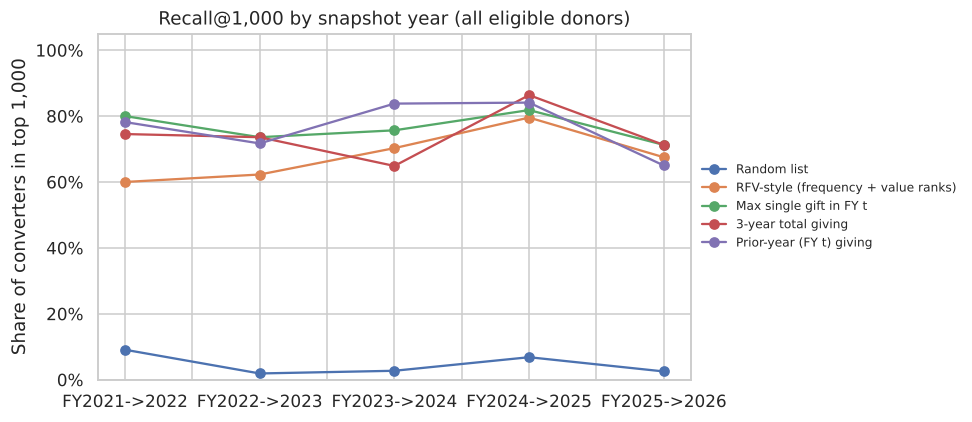

In [34]:
fig, ax = plt.subplots(figsize=(9, 4))
pv_ = base_k[base_k["population"] == "All eligible"].pivot(index="snapshot", columns="rule", values="recall")[list(rules)]
pv_.index = [f"FY{t}->{t + 1}" for t in pv_.index]
pv_.plot(ax=ax, marker="o")
ax.yaxis.set_major_formatter(mtick.PercentFormatter(1))
ax.set(title=f"Recall@{K:,} by snapshot year (all eligible donors)", ylabel="Share of converters in top 1,000", ylim=(0, 1.05))
ax.legend(frameon=False, fontsize=8, loc="center left", bbox_to_anchor=(1, 0.5))
plt.tight_layout()

**Simple rules are already strong, and this is the bar a model must clear.**
- Ranking eligible donors by **prior-year giving** puts about **77% of next-year converters in the top 1,000**, a lift of about 25× over the overall conversion rate. **Max single gift** (76%) and **three-year total** (74%) do about as well.
- The **RFV-style score** (frequency + value) is weaker, at 68%. Weighting how often someone gives dilutes the value signal.
- **Among never-major donors** the task is harder: the best rule (prior-year giving) captures about 63%, and three-year total only 50%.
- Recall swings by roughly ±10 points from year to year. With about 50 converters a year, a model's apparent gain of a few points could be noise.

*Implication:* A useful model must beat about 77% recall at 1,000 overall, and about 63% for never-major donors. Each year only about 265 donors give around $600, so they already fit in the top 1,000. The real room for improvement is **finding the converters who come from lower bands** (the $101–250 band alone produced 61 of 269), and ordering the rest of the list well.

## 13. Results

### Summary of findings
1. **Data structure.** The nine tables join cleanly on constituent ID. The apparent orphan and unlinked rows are **defective copies** of real records: 36,044 payments, 113 soft credits, and 216,128 legacy rows. They were removed, along with 79 duplicate soft credits and 59 constant or blank columns.
2. **Building giving.** Fiscal-year giving = positive personal payments + deduplicated soft credits, with org hard credits excluded (they equal the soft credits). This yields 199,772 donor-years for 71,811 donors, FY2021–26.
3. **The target is rare.** Major donors ($1,200+) are 0.25–0.38% of donors and 5–11% of revenue. 12-month conversion is **0.17%** (about 54 a year). Former majors are 0.6% of eligible donors but 51% of converters.
4. **Strongest predictors.** Prior-year giving (especially the $600 level), three-year total, former-major status, soft credits, and upgrade gifts. Sustainers renew more but convert less.
5. **Weak or no signal.** Solicitations and Passport viewing add nothing once giving is known. Age adds a little.
6. **Leakage.** Giving group, major-donor class, the sustainer flag, and the UofU dollar fields are rebuilt from FY2025–26 giving. Exclude them.
7. **Cultivation works after adoption.** Contact nearly triples conversion relative to random holdouts (5.5% vs. 1.9%). Before adoption there is little effect.
8. **Baselines.** Ranking by prior-year giving already captures about 77% of converters in the top 1,000 (63% for never-major donors).

### Implications for modeling
- **Unit and target.** Eligible donor-years (gave in FY *t*, under $1,200). Primary target: $1,200+ in FY *t* + 1. Secondary targets: 3- and 5-year conversion, and a coarse tier.
- **Validation.** Rolling time-based backtests (train on earlier snapshots, test on the next), keeping spouses in the same fold. Never split randomly by row. Expect a shift in FY2026.
- **Metrics.** Recall, precision, and lift at K = 1,000 (and smaller K), plus PR-AUC. Report separately for never-major donors. Always compare against the prior-year-giving baseline.
- **Features.** Prior-year amount, three-year total, max gift, former major, soft-credit/DAF flags, upgrade flag, recurring flag, years given in the last five, tenure including legacy history, and age at *t*. Exclude snapshot and cultivation fields from the baseline model.
- **Next step.** Because contact has a measurable effect, consider an uplift analysis so officers select the donors whose conversion *changes* most with contact.

### Open questions for the sponsor
- Are the defective copies (orphan payments, unlinked legacy gifts) intentional in this release?
- What does `tender_type = "Legacy"` mean?
- What exactly does "contacted" mean in portfolios that had not yet adopted the program?
- Should success count first-time major donors only, or also returning former majors?